# Imports

In [1]:
import numpy as np
import pandas as pd
import torch
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
import umap
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel
from Bio.Seq import Seq

/Users/julianmckinley/miniforge3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Configuration

In [2]:
MAIN_CSV_PATH = "mRNA_Stability.csv"
CONTROL_CSV_PATH = "mRFP_Expression.csv"
SEQ_COLUMN = "Sequence"        # check the real header once you have the file open
LABEL_COLUMN = "Value"         # check the real header once you have the file open
LABEL_IS_CONTINUOUS = True     # True for a regression style label
N_ROWS = 1000                  # keep the first pass small and fast

RNA_MODEL_NAME = "InstaDeepAI/nucleotide-transformer-500m-human-ref"
PROTEIN_MODEL_NAME = "facebook/esm2_t12_35M_UR50D"
RNA_MAX_LEN = 1000
PROTEIN_MAX_LEN = 1024

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cpu


# Model Loading and Embedding Functions

In [3]:
def load_encoder(name):
    tok = AutoTokenizer.from_pretrained(name, trust_remote_code=True)
    model = AutoModel.from_pretrained(name, trust_remote_code=True).to(DEVICE).eval()
    return tok, model

@torch.no_grad()
def embed(seq, tok, model, max_len=1024):
    inputs = tok(seq, return_tensors="pt", truncation=True, max_length=max_len).to(DEVICE)
    out = model(**inputs)
    return out.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()

# Sequence Helper Functions

In [4]:
def is_in_frame_and_starts_correctly(seq):
    """Length is a multiple of 3, and it starts with a start codon,
    whether written in DNA form (ATG) or RNA form (AUG)."""
    seq = seq.upper().strip()
    return len(seq) % 3 == 0 and seq.startswith(("ATG", "AUG"))

def translate_cds(seq):
    trimmed = seq[: len(seq) - (len(seq) % 3)]
    return str(Seq(trimmed).translate(to_stop=True))

def rna_to_dna(seq):
    return seq.upper().replace("U", "T")

# Linear Probing and CKA Functions

In [5]:
from sklearn.linear_model import RidgeCV

def run_probe(X, y, continuous, name):
    X = StandardScaler().fit_transform(X)
    if continuous:
        model = RidgeCV(alphas=np.logspace(-3, 5, 20))
        scores = cross_val_score(model, X, y, cv=5, scoring="r2")
        print(f"  Linear probe on {name} embeddings, R^2 (5 fold): {scores.mean():.3f} +/- {scores.std():.3f}")
    else:
        scores = cross_val_score(LogisticRegression(max_iter=2000), X, y, cv=5, scoring="accuracy")
        print(f"  Linear probe on {name} embeddings, accuracy (5 fold): {scores.mean():.3f} +/- {scores.std():.3f}")

def linear_cka(X, Y):
    X = X - X.mean(axis=0, keepdims=True)
    Y = Y - Y.mean(axis=0, keepdims=True)
    hsic = np.linalg.norm(Y.T @ X, ord="fro") ** 2
    norm_x = np.linalg.norm(X.T @ X, ord="fro")
    norm_y = np.linalg.norm(Y.T @ Y, ord="fro")
    return hsic / (norm_x * norm_y)

# Dataset Embedding Function

In [6]:
def embed_dataset(df, rna_tok, rna_model, prot_tok, prot_model, seq_col, label_col=None):
    rna_embeds, prot_embeds, labels, protein_strings = [], [], [], []
    dropped_out_of_frame = 0

    for _, row in df.iterrows():
        seq = str(row[seq_col]).strip().upper()

        if not is_in_frame_and_starts_correctly(seq):
            dropped_out_of_frame += 1
            continue

        protein_seq = translate_cds(seq)
        if len(protein_seq) < 5:
            continue

        rna_embeds.append(embed(rna_to_dna(seq), rna_tok, rna_model, max_len=RNA_MAX_LEN))
        prot_embeds.append(embed(protein_seq, prot_tok, prot_model, max_len=PROTEIN_MAX_LEN))
        protein_strings.append(protein_seq)
        if label_col is not None and label_col in df.columns:
            labels.append(row[label_col])

    if dropped_out_of_frame:
        print(f"  Dropped {dropped_out_of_frame} sequences that were not in frame or did not start with a start codon.")

    rna_embeds = np.vstack(rna_embeds) if rna_embeds else np.empty((0,))
    prot_embeds = np.vstack(prot_embeds) if prot_embeds else np.empty((0,))
    labels = np.array(labels) if labels else None
    return rna_embeds, prot_embeds, protein_strings, labels

# Load the Encoders

In [7]:
rna_tok, rna_model = load_encoder(RNA_MODEL_NAME)
prot_tok, prot_model = load_encoder(PROTEIN_MODEL_NAME)
print("Encoders loaded.")

Loading weights: 100%|██████████| 390/390 [00:00<00:00, 45029.28it/s]
[transformers] EsmModel LOAD REPORT from: InstaDeepAI/nucleotide-transformer-500m-human-ref
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.decoder.weight    | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading weights: 100%|██████████| 198/198 [00:00<00:00, 6951.71it/s]
[transformers] EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                       | Sta

Encoders loaded.


# Embed the Main Dataset (mRNA_Stability)

In [8]:
main_df = pd.read_csv(MAIN_CSV_PATH).dropna(subset=[SEQ_COLUMN]).sample(n=N_ROWS, random_state=42)
rna_embeds, prot_embeds, _, labels = embed_dataset(
    main_df, rna_tok, rna_model, prot_tok, prot_model, SEQ_COLUMN, LABEL_COLUMN
)
print(f"Embedded {len(rna_embeds)} sequences.")

np.savez(
    "stage1_main_embeddings.npz",
    rna=rna_embeds, protein=prot_embeds,
    labels=labels if labels is not None else np.array([]),
)

  Dropped 19 sequences that were not in frame or did not start with a start codon.
Embedded 981 sequences.


In [9]:
print("RNA embedding shape:", rna_embeds.shape)
print("Protein embedding shape:", prot_embeds.shape)

RNA embedding shape: (981, 1280)
Protein embedding shape: (981, 480)


981 of 1000 sampled sequences survived the frame and start codon filter, a 98 percent retention rate. The RNA embeddings are 1280 dimensional (Nucleotide Transformer) and the protein embeddings are 480 dimensional (ESM-2), confirming both encoders loaded and ran correctly before trusting any of the analysis below.

# Stage 1: Representation Analysis

Three tracks, each answering a different question about the frozen encoders: Track A (Decodability), Track B (Cross-Modal Geometry), Track C (Interpretability, to be added below).

# Stage 1, Track A: Decodability, Linear Probing

In [10]:
if labels is not None and len(labels) == len(rna_embeds):
    print("Linear probing (RNA-only vs protein-only, the Stage 1 preview of Mina's key comparison):")
    run_probe(rna_embeds, labels, LABEL_IS_CONTINUOUS, "RNA")
    run_probe(prot_embeds, labels, LABEL_IS_CONTINUOUS, "protein")
else:
    print(f"No usable '{LABEL_COLUMN}' column found or length mismatch, skipping linear probing.")

Linear probing (RNA-only vs protein-only, the Stage 1 preview of Mina's key comparison):
  Linear probe on RNA embeddings, R^2 (5 fold): 0.059 +/- 0.007
  Linear probe on protein embeddings, R^2 (5 fold): 0.113 +/- 0.066


Both encoders show real, positive signal on their own, RNA at R² of 0.059 and protein at R² of 0.113. Neither is large, but both are clearly above zero, meaning a simple linear model recovers real stability information from a single frozen embedding with no training beyond the probe itself. Protein's point estimate is nearly double RNA's, though its wider fold-to-fold variability (± 0.066 versus ± 0.007) means the two are not cleanly separable without a direct significance test between them.

# Stage 1, Track A: Decodability, Length Baseline (Control)

In [11]:
def get_lengths_for_kept_rows(df, seq_col):
    lengths = []
    for _, row in df.iterrows():
        seq = str(row[seq_col]).strip().upper()
        if not is_in_frame_and_starts_correctly(seq):
            continue
        protein_seq = translate_cds(seq)
        if len(protein_seq) < 5:
            continue
        lengths.append(len(seq))
    return np.array(lengths).reshape(-1, 1)

seq_lengths = get_lengths_for_kept_rows(main_df, SEQ_COLUMN)
print("Length-only baseline (trivial predictor, for comparison against RNA/protein):")
run_probe(seq_lengths, labels, LABEL_IS_CONTINUOUS, "sequence length only")

Length-only baseline (trivial predictor, for comparison against RNA/protein):
  Linear probe on sequence length only embeddings, R^2 (5 fold): 0.007 +/- 0.011


Sequence length alone predicts almost nothing about stability, R² of 0.007, essentially indistinguishable from zero. This rules out the concern that the RNA and protein probe scores above are secretly just a proxy for sequence length rather than real embedding content.

# Stage 1, Track A: Decodability, GC Content Probe

In [12]:
def get_seqs_for_kept_rows(df, seq_col):
    kept = []
    for _, row in df.iterrows():
        seq = str(row[seq_col]).strip().upper()
        if not is_in_frame_and_starts_correctly(seq):
            continue
        if len(translate_cds(seq)) < 5:
            continue
        kept.append(seq)
    return kept

def gc_content(seq):
    return (seq.count("G") + seq.count("C")) / len(seq)

kept_seqs = get_seqs_for_kept_rows(main_df, SEQ_COLUMN)
seq_gc = np.array([gc_content(s) for s in kept_seqs]).reshape(-1, 1)

print("Does the RNA embedding linearly encode GC content (a basic, known property)?")
run_probe(rna_embeds, seq_gc.ravel(), True, "RNA (predicting GC content)")
print("\nDoes the protein embedding linearly encode GC content of its source sequence?")
run_probe(prot_embeds, seq_gc.ravel(), True, "protein (predicting GC content)")

Does the RNA embedding linearly encode GC content (a basic, known property)?
  Linear probe on RNA (predicting GC content) embeddings, R^2 (5 fold): 0.986 +/- 0.003

Does the protein embedding linearly encode GC content of its source sequence?
  Linear probe on protein (predicting GC content) embeddings, R^2 (5 fold): 0.681 +/- 0.044


This confirms both encoders demonstrably capture real, known biology rather than something biologically meaningless. RNA nearly perfectly recovers GC content (R² of 0.986), expected since GC content is a direct compositional property of the nucleotide sequence itself. Protein recovering 0.681 of that same signal is the more interesting result, since GC content is not a protein property. This reflects the genetic code's redundancy: different amino acids are preferentially encoded by GC-rich versus AT-rich codons, so a protein's amino acid composition carries a real, indirect signature of the GC content of the gene that produced it. This is a documented biological phenomenon, not a leak or an artifact.

# Stage 1, Track B: Cross-Modal Geometry, Synergy Check (Naive Concatenation)

In [13]:
concat_embeds = np.hstack([rna_embeds, prot_embeds])
print("Synergy check (naive concatenation vs best single modality):")
run_probe(concat_embeds, labels, LABEL_IS_CONTINUOUS, "RNA+protein concatenated")

Synergy check (naive concatenation vs best single modality):
  Linear probe on RNA+protein concatenated embeddings, R^2 (5 fold): 0.115 +/- 0.064


Naive concatenation of RNA and protein embeddings scores R² of 0.115 versus 0.113 for protein alone, a difference of 0.002 entirely within the noise of both scores' standard deviations. At the level of simple concatenation, there is no measurable synergy between the two modalities for predicting stability. This does not mean fusion is a dead end, it means a fusion mechanism has to do more than concatenate raw embeddings to extract additional value, which is exactly why the field builds learned fusion modules like cross-attention rather than relying on concatenation alone.

# Stage 1, Track B: Cross-Modal Geometry, CKA

In [14]:
print("Linear CKA, RNA vs protein:", f"{linear_cka(rna_embeds, prot_embeds):.3f}")

Linear CKA, RNA vs protein: 0.128


CKA of 0.128 indicates the two embedding spaces are, taken as a whole, structured quite differently from each other rather than being redundant copies of the same information. Combined with the synergy check above, this is a reasonable place to be: the two modalities are not simply duplicating each other, though that alone does not guarantee a fusion module will find something useful to combine, it only rules out the case where fusion would obviously be pointless.

# Stage 1, Track B: Cross-Modal Geometry, Layer-wise CKA

In [19]:
LAYERWISE_N_ROWS = 200

@torch.no_grad()
def embed_all_layers(seq, tok, model, max_len=1024):
    inputs = tok(seq, return_tensors="pt", truncation=True, max_length=max_len).to(DEVICE)
    out = model(**inputs, output_hidden_states=True)
    return [h.mean(dim=1).squeeze().cpu().numpy() for h in out.hidden_states]

def embed_dataset_all_layers(df, rna_tok, rna_model, prot_tok, prot_model, seq_col):
    rna_layers_per_seq, prot_layers_per_seq = [], []

    for _, row in df.iterrows():
        seq = str(row[seq_col]).strip().upper()
        if not is_in_frame_and_starts_correctly(seq):
            continue
        protein_seq = translate_cds(seq)
        if len(protein_seq) < 5:
            continue

        rna_layers_per_seq.append(embed_all_layers(rna_to_dna(seq), rna_tok, rna_model, max_len=RNA_MAX_LEN))
        prot_layers_per_seq.append(embed_all_layers(protein_seq, prot_tok, prot_model, max_len=PROTEIN_MAX_LEN))

    n_rna_layers = len(rna_layers_per_seq[0])
    n_prot_layers = len(prot_layers_per_seq[0])
    rna_layer_matrices = [np.vstack([s[l] for s in rna_layers_per_seq]) for l in range(n_rna_layers)]
    prot_layer_matrices = [np.vstack([s[l] for s in prot_layers_per_seq]) for l in range(n_prot_layers)]
    return rna_layer_matrices, prot_layer_matrices

layerwise_df = main_df.sample(n=min(LAYERWISE_N_ROWS, len(main_df)), random_state=42)
rna_layer_matrices, prot_layer_matrices = embed_dataset_all_layers(
    layerwise_df, rna_tok, rna_model, prot_tok, prot_model, SEQ_COLUMN
)

n_rna_layers, n_prot_layers = len(rna_layer_matrices), len(prot_layer_matrices)
print(f"RNA encoder: {n_rna_layers} hidden state outputs (embedding layer plus each transformer layer).")
print(f"Protein encoder: {n_prot_layers} hidden state outputs.")

cka_matrix = np.zeros((n_rna_layers, n_prot_layers))
for i in range(n_rna_layers):
    for j in range(n_prot_layers):
        cka_matrix[i, j] = linear_cka(rna_layer_matrices[i], prot_layer_matrices[j])

best_rna, best_prot = np.unravel_index(cka_matrix.argmax(), cka_matrix.shape)
print(f"\nMaximum layer-wise CKA: {cka_matrix.max():.3f}, at RNA layer {best_rna}, protein layer {best_prot}")
print(f"Final-layer-only CKA for comparison: {cka_matrix[-1, -1]:.3f}")

RNA encoder: 25 hidden state outputs (embedding layer plus each transformer layer).
Protein encoder: 13 hidden state outputs.

Maximum layer-wise CKA: 0.400, at RNA layer 16, protein layer 0
Final-layer-only CKA for comparison: 0.187


In [21]:
non_embed_max = cka_matrix[:, 1:].max()
non_embed_rna, non_embed_prot = np.unravel_index(cka_matrix[:, 1:].argmax(), cka_matrix[:, 1:].shape)
print(f"Best alignment excluding the protein embedding layer: {non_embed_max:.3f}, at RNA layer {non_embed_rna}, protein layer {non_embed_prot + 1}")

Best alignment excluding the protein embedding layer: 0.359, at RNA layer 0, protein layer 1


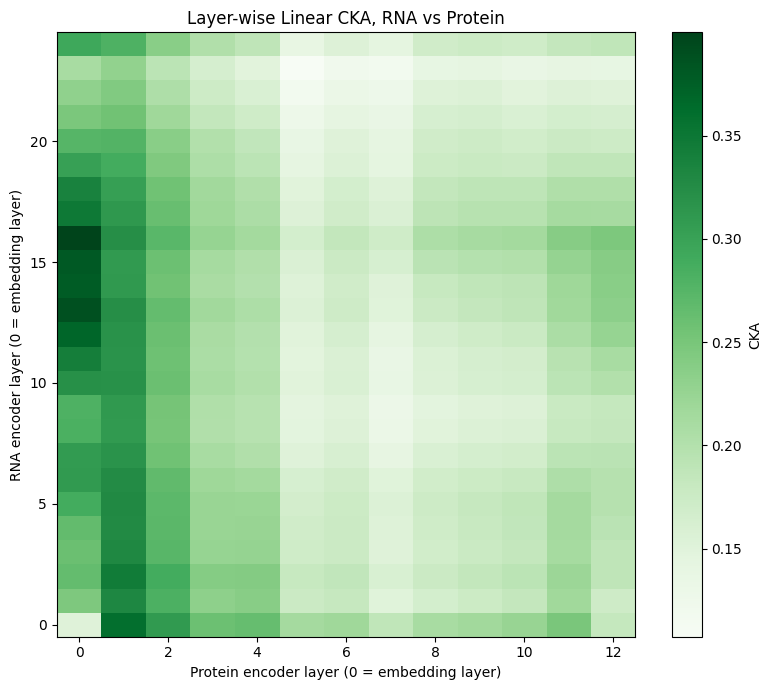

In [20]:
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cka_matrix, cmap="Greens", aspect="auto", origin="lower")
ax.set_xlabel("Protein encoder layer (0 = embedding layer)")
ax.set_ylabel("RNA encoder layer (0 = embedding layer)")
ax.set_title("Layer-wise Linear CKA, RNA vs Protein")
plt.colorbar(im, ax=ax, label="CKA")
plt.tight_layout()
plt.show()

The layer-wise breakdown confirms the RNA encoder has 24 transformer layers and the protein encoder has 12, matching both models' published architectures and confirming output_hidden_states captured every layer as intended. The final-layer CKA recomputed here on this 200-sequence subsample is 0.187, higher than the 0.128 computed earlier on the full 981-sequence sample. Since hidden_states[-1] is mathematically identical to the pooled output used in the original CKA cell, this gap reflects sampling noise from the much smaller subsample rather than a change in what is being measured, a reminder that CKA estimates at n=200 carry real variance and the exact heatmap values should be read as indicative rather than precise.

The overall peak is 0.400, at RNA layer 16 of 24 against protein layer 0, the protein encoder's embedding layer, before self-attention has mixed any context into it. Restricting the search to protein's contextualized layers only drops the peak to 0.359, and that second peak sits at RNA layer 0, the RNA encoder's own embedding layer, against protein layer 1, its first transformer layer. So the two strongest alignment points in the entire matrix both involve one encoder sitting at or immediately next to its embedding layer rather than two deeply contextualized representations meeting in the middle. Mean-pooled embedding layers are close to context-free composition summaries, nucleotide or amino acid identity and frequency, with no information about arrangement or learned function. This is consistent with the GC content probe result earlier in the notebook: genetic code redundancy means amino acid composition carries a real signature of the source gene's GC content, so a compositional signal on each side, not a deep semantic one, looks like the more likely driver of most of the measured cross-modal alignment here.

This tempers, without undoing, the fusion argument made after the CCA and retrieval results above. Compositional cross-modal correspondence is still real, documented biology and still worth a fusion mechanism being able to exploit, but it is a more modest claim than deep functional alignment between the two encoders' learned representations. The honest summary is that this pipeline has found a genuine but largely compositional bridge between RNA and protein embeddings, rather than evidence that the two encoders converge on shared higher order biological meaning.

# Stage 1, Track B: Cross-Modal Geometry, Mutual k-NN, CCA, and Retrieval

In [15]:
from sklearn.neighbors import NearestNeighbors

def mutual_knn_alignment(X, Y, k=10):
    n = X.shape[0]
    neighbors_x = NearestNeighbors(n_neighbors=k + 1).fit(X).kneighbors(X, return_distance=False)
    neighbors_y = NearestNeighbors(n_neighbors=k + 1).fit(Y).kneighbors(Y, return_distance=False)
    overlaps = [len(set(neighbors_x[i, 1:]) & set(neighbors_y[i, 1:])) / k for i in range(n)]
    return np.mean(overlaps)

score = mutual_knn_alignment(rna_embeds, prot_embeds, k=10)
print(f"Mutual k-NN alignment (k=10), RNA vs protein: {score:.3f}")
print(f"Chance level for {len(rna_embeds)} points: roughly {10/len(rna_embeds):.4f}")

Mutual k-NN alignment (k=10), RNA vs protein: 0.070
Chance level for 981 points: roughly 0.0102


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import CCA

train_idx, test_idx = train_test_split(np.arange(len(rna_embeds)), test_size=0.3, random_state=42)

pca_rna = PCA(n_components=50, random_state=42).fit(rna_embeds[train_idx])
pca_prot = PCA(n_components=50, random_state=42).fit(prot_embeds[train_idx])

rna_train_r, prot_train_r = pca_rna.transform(rna_embeds[train_idx]), pca_prot.transform(prot_embeds[train_idx])
rna_test_r, prot_test_r = pca_rna.transform(rna_embeds[test_idx]), pca_prot.transform(prot_embeds[test_idx])

cca = CCA(n_components=10).fit(rna_train_r, prot_train_r)
rna_test_c, prot_test_c = cca.transform(rna_test_r, prot_test_r)

print("Canonical correlations on held-out test data:")
for i in range(10):
    corr = np.corrcoef(rna_test_c[:, i], prot_test_c[:, i])[0, 1]
    print(f"  Component {i + 1}: {corr:.3f}")

from sklearn.neighbors import NearestNeighbors
n_test = len(test_idx)
nn = NearestNeighbors(n_neighbors=min(10, n_test)).fit(prot_test_c)
_, neighbor_idx = nn.kneighbors(rna_test_c)

print("\nCross-modal retrieval on held-out test data:")
for k in (1, 5, 10):
    correct = sum(i in neighbor_idx[i, :k] for i in range(n_test))
    print(f"  Recall@{k}: {correct / n_test:.3f} (chance level: {k / n_test:.4f})")

Canonical correlations on held-out test data:
  Component 1: 0.955
  Component 2: 0.914
  Component 3: 0.846
  Component 4: 0.872
  Component 5: 0.786
  Component 6: 0.772
  Component 7: 0.588
  Component 8: 0.670
  Component 9: 0.537
  Component 10: 0.584

Cross-modal retrieval on held-out test data:
  Recall@1: 0.366 (chance level: 0.0034)
  Recall@5: 0.614 (chance level: 0.0169)
  Recall@10: 0.759 (chance level: 0.0339)


Mutual k-nearest-neighbor overlap of 0.070, against a chance level of roughly 0.010 for this sample size, confirms the same modest but real global alignment CKA found, about seven times above what random embeddings would show. Read alongside CKA, both metrics agree that RNA and protein embeddings are only loosely related when compared as whole spaces.

The CCA and retrieval results tell a different, more encouraging part of the story, and reconcile with the synergy check above rather than contradicting it. Canonical correlations reach as high as 0.955 in the top component, computed on held-out data so this is not overfitting, and cross-modal retrieval built on that same learned subspace finds the correct matching protein embedding as the top candidate 36.6 percent of the time, against a chance level of 0.3 percent. CKA and mutual k-NN measure whether the two full representation spaces agree overall, treating every direction as equally important. CCA instead searches specifically for whatever narrow subspace is maximally correlated between the two spaces, even if that subspace is a small slice of each encoder's total variance. Together these results say RNA and protein embeddings are mostly encoding different things, consistent with the low CKA, but there is a specific, strong, learnable shared axis buried in both of them, plausibly the same compositional signal the GC content probe surfaced above. That explains why naive concatenation showed no synergy: concatenation does not know where to look for that shared axis, while CCA, given the freedom to search for it, finds it easily. This is the strongest argument in this Stage 1 pilot for why a trained fusion mechanism, rather than simple concatenation, is worth building: real cross-modal structure exists, it simply is not accessible without a method that can learn where to find it.

# Stage 1, Track B: Cross-Modal Geometry, UMAP (Qualitative Only)

/Users/julianmckinley/miniforge3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/julianmckinley/miniforge3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


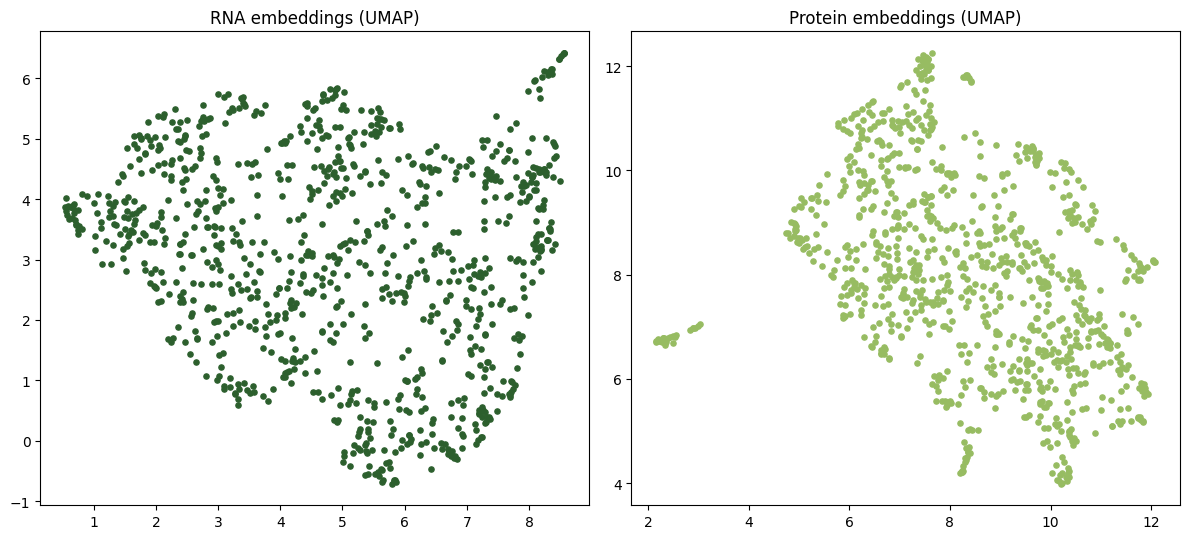

In [17]:
coords_rna = umap.UMAP(random_state=42).fit_transform(rna_embeds)
coords_prot = umap.UMAP(random_state=42).fit_transform(prot_embeds)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
axes[0].scatter(coords_rna[:, 0], coords_rna[:, 1], s=14, color="#2C5F2D")
axes[0].set_title("RNA embeddings (UMAP)")
axes[1].scatter(coords_prot[:, 0], coords_prot[:, 1], s=14, color="#97BC62")
axes[1].set_title("Protein embeddings (UMAP)")
plt.tight_layout()
plt.show()

Both RNA and protein embeddings show one large main cluster plus a small handful of points that separate out on their own. Two independently trained encoders isolating the same small subgroup is unlikely to be coincidental, and it may reflect a species subpopulation within this multi species dataset (human, mouse, frog, fish). This is illustrative rather than evidence on its own, but worth a follow up check against the dataset's species column if time allows.

# Stage 1, Pipeline Validation, Control Dataset Check (mRFP_Expression)

In [18]:
print("Every variant here is a synonymous recoding of one gene, so they should")
print("all translate to the identical protein. This checks that the pipeline")
print("actually behaves that way before trusting results on the main dataset.\n")

control_df = pd.read_csv(CONTROL_CSV_PATH).dropna(subset=[SEQ_COLUMN]).sample(n=N_ROWS, random_state=42)
control_rna, control_prot, control_proteins, _ = embed_dataset(
    control_df, rna_tok, rna_model, prot_tok, prot_model, SEQ_COLUMN
)

unique_proteins = set(control_proteins)
print(f"Unique translated protein sequences across {len(control_proteins)} variants: {len(unique_proteins)}")
if len(unique_proteins) == 1:
    print("  As expected: every variant encodes the same protein.")
else:
    print("  Unexpected: variants encode different proteins. Check the frame and start codon on this file.")

if len(control_prot) > 1:
    protein_spread = np.linalg.norm(control_prot - control_prot.mean(axis=0), axis=1).mean()
    rna_spread = np.linalg.norm(control_rna - control_rna.mean(axis=0), axis=1).mean()
    print(f"  Average distance to centroid, protein embeddings: {protein_spread:.5f} (should be near zero)")
    print(f"  Average distance to centroid, RNA embeddings:     {rna_spread:.5f} (should be clearly nonzero)")

Every variant here is a synonymous recoding of one gene, so they should
all translate to the identical protein. This checks that the pipeline
actually behaves that way before trusting results on the main dataset.

Unique translated protein sequences across 1000 variants: 1
  As expected: every variant encodes the same protein.
  Average distance to centroid, protein embeddings: 0.00003 (should be near zero)
  Average distance to centroid, RNA embeddings:     4.72361 (should be clearly nonzero)


All 1000 mRFP_Expression variants translate to a single identical protein sequence, exactly as expected since they are synonymous recodings of one gene. Protein embeddings for these variants collapse almost to a single point (average distance to centroid of 0.00003), while RNA embeddings, which do see the codon level differences, spread out clearly (4.72). This confirms the translation, frame checking, and embedding pipeline behaves correctly, which is what makes the R², CKA, GC content, and CCA results on the main dataset above trustworthy rather than artifacts of a broken pipeline.

# Stage 1, Track C: Interpretability, Overview

Track A asked whether the frozen encoders' embeddings contain decodable information at all. Track B asked how the two modalities' representation spaces relate to each other geometrically. Track C opens the encoders themselves: does the frozen RNA encoder's attention actually track real regulatory biology, rather than surface or compositional patterns, and does the degree of cross-modal alignment predict downstream performance well enough to tell us whether an explicit alignment loss in Stage 2's fusion architecture would help or hurt.

# Stage 1, Track C: Interpretability, Attention Extraction From the Frozen Encoder

Tracks A and B only ever looked at the encoders' final pooled output vector, treating the model itself as a black box. This step opens the box: it reuses the already-loaded frozen RNA encoder, but requests `output_attentions=True` instead of `output_hidden_states=True`, mirroring the existing embedding pattern used everywhere above. The result is one attention tensor per transformer layer, each shaped (heads, sequence length, sequence length), recording how much of every token's representation was built from every other token. This is the raw material the rest of Track C compares against real regulatory motifs.

One gotcha to flag before running this: recent `transformers` releases default many ESM-based architectures, including this RNA encoder, to the "sdpa" attention implementation, which cannot return per-head attention weights even when `output_attentions=True` is passed. Getting real output here requires loading a second copy of the model with `attn_implementation="eager"`, kept as its own object so the already-computed Track A and Track B results are never touched.

In [1]:
import torch
import numpy as np

def get_attention_maps(model, tokenizer, sequence, device="cpu"):
    """
    Runs one sequence through a frozen encoder and pulls its attention weights,
    mirroring your existing get_embeddings() pattern but with output_attentions=True
    instead of output_hidden_states=True.
    """
    inputs = tokenizer(sequence, return_tensors="pt", truncation=True).to(device)
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)
    # outputs.attentions is a tuple, one tensor per layer
    # each tensor's shape is (batch=1, num_heads, seq_len, seq_len)
    attentions = [layer_att.squeeze(0).cpu().numpy() for layer_att in outputs.attentions]
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    return attentions, tokens

# Stage 1, Track C: Interpretability, Aggregating Attention Into One Score Per Position

A single layer's attention is a full (heads x positions x positions) tensor, too much to interpret position by position. This step collapses it to one score per sequence position by averaging across all attention heads within a chosen layer, then summing how much attention each position receives from every other position ("incoming" attention, as opposed to how much it sends out). A position many other positions rely on gets a high score. The score is min-max normalized to [0, 1] so it is comparable across sequences of different lengths. The default, `layer=-1`, uses the last transformer layer, since final layers tend to hold the most semantically refined attention.

In [2]:
def aggregate_attention(attentions, layer=-1, mode="incoming"):
    """
    layer=-1 uses the last layer, which tends to hold the most semantically
    refined attention. mode="incoming" measures, for each position, how much
    attention it RECEIVES from everywhere else, averaged across all heads.
    High incoming attention means many other positions rely on that spot,
    which is what you want if you're asking "is this position important".
    """
    layer_att = attentions[layer].mean(axis=0)  # average across heads -> (seq_len, seq_len)
    score = layer_att.sum(axis=0) if mode == "incoming" else layer_att.sum(axis=1)
    score = (score - score.min()) / (score.max() - score.min() + 1e-8)
    return score

# Stage 1, Track C: Interpretability, Motif Scanning (JASPAR)

This step is independent of the model entirely: it establishes the ground truth to compare attention against. JASPAR is a curated, public database of real transcription-factor binding motifs, represented as position weight matrices. This scans a given sequence for high-scoring matches to a chosen set of motifs and returns the position, motif name, and match strength for every hit above a score threshold. The two motif IDs here are placeholders and should be swapped for motifs actually biologically relevant to mRNA stability before this is used for a real result. RNA's uracil is treated as DNA's thymine for the scan, a standard convention since JASPAR motifs are defined on DNA, coding-strand sequence.

In [5]:
!pip install pyjaspar --break-system-packages
from pyjaspar import jaspardb
from Bio.Seq import Seq

jdb = jaspardb(release="JASPAR2024")

motif_ids = ["MA0139.1", "MA0442.1"]  # placeholders, replace with motifs relevant to your genes
motif_objs = [jdb.fetch_motif_by_id(mid) for mid in motif_ids]

def scan_sequence_for_motifs(sequence, motif_objs, threshold=4.0):
    """
    JASPAR motifs are defined on DNA. RNA's U is treated as DNA's T for scanning,
    which is standard since these motifs are defined on the coding strand anyway.
    Returns (start, end, motif_name, score) for every hit.
    """
    dna_seq = Seq(sequence.upper().replace("U", "T"))
    hits = []
    for motif in motif_objs:
        for position, score in motif.pssm.search(dna_seq, threshold=threshold):
            start = position if position >= 0 else len(dna_seq) + position
            hits.append((start, start + len(motif), motif.name, score))
    return hits

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 MB 31.8 MB/s  0:00:01m0:00:0100:01

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


# Stage 1, Track C: Interpretability, Attention-Motif Overlap Test

This is the actual interpretability test, connecting the previous two steps: does the model's attention (the per-position score from Step 2) land more heavily on the real regulatory motif positions found in Step 3, compared to everywhere else in the sequence? A one-sided Mann-Whitney U test compares attention scores at motif positions against attention scores at all other positions, testing whether motif positions are stochastically greater. A small p-value together with a higher mean attention at motif positions is the actual finding: evidence the frozen encoder learned to attend to real regulatory biology rather than arbitrary or purely compositional patterns. This is the result that would let Mina cite genuine mechanistic evidence for what the encoder has learned, beyond decodability alone.

In [6]:
from scipy.stats import mannwhitneyu

def attention_motif_overlap(attention_score, motif_hits):
    """
    Compares attention scores at motif-hit positions against everywhere else.
    If the model learned real regulatory biology rather than surface noise,
    attention should be significantly higher at motif positions.
    """
    motif_positions = set()
    for start, end, name, score in motif_hits:
        motif_positions.update(range(start, min(end, len(attention_score))))
    non_motif_positions = set(range(len(attention_score))) - motif_positions

    if not motif_positions or not non_motif_positions:
        return None

    motif_scores = attention_score[list(motif_positions)]
    non_motif_scores = attention_score[list(non_motif_positions)]
    stat, pval = mannwhitneyu(motif_scores, non_motif_scores, alternative="greater")
    return {
        "mean_attention_at_motifs": motif_scores.mean(),
        "mean_attention_elsewhere": non_motif_scores.mean(),
        "n_motif_positions": len(motif_positions),
        "p_value": pval,
    }

# Stage 1, Track C: Interpretability, Visualizing Examples

Turns one sequence's aggregated attention score (Step 2) and motif hits (Step 3) into a single annotated plot: the attention score drawn as a line and shaded area across sequence position, with each motif hit overlaid as a shaded vertical band and labeled by motif name. This is a qualitative companion to the statistical test in Step 4, an actual picture showing individual examples of whether high-attention regions visually coincide with real motif locations.

In [7]:
import matplotlib.pyplot as plt

def plot_attention_with_motifs(attention_score, motif_hits, title=""):
    fig, ax = plt.subplots(figsize=(14, 3))
    ax.plot(attention_score, color="black", linewidth=1)
    ax.fill_between(range(len(attention_score)), attention_score, color="gray", alpha=0.3)
    for start, end, name, score in motif_hits:
        ax.axvspan(start, end, color="black", alpha=0.15)
        ax.text(start, max(attention_score) * 1.02, name, fontsize=7, rotation=90)
    ax.set_xlabel("Sequence position")
    ax.set_ylabel("Attention score (normalized)")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

# Stage 1, Track C: Interpretability, Alignment-Performance Slope (Diagnostic for Stage 2)

This implements the alignment-performance-slope diagnostic from the alignment-theory framework this project is using (Tjandrasuwita et al., ICML 2025). Track B's CKA and mutual k-NN ask whether the two modalities are aligned on average. This asks a sharper, per-sample question instead: does the degree of local alignment between one specific RNA-protein pair predict how well a downstream model does on that specific sample?

Local alignment is measured as the cosine similarity between the two modalities' representations in the shared space the Track B CCA step already established, not the raw encoder embeddings, which live in different-dimensional spaces (1280 for RNA, 480 for protein) and are not directly comparable. A simple linear model is trained with 5-fold cross-validation on the concatenated representations to predict the stability label, and the resulting per-sample prediction errors are compared against local alignment via Spearman correlation.

A negative, significant correlation means tightly-aligned samples get predicted more accurately, direct evidence an explicit alignment loss in Stage 2's fusion architecture would likely help. A null or positive result means alignment does not track performance here, the pattern the paper associates with real, high modality uniqueness, and a reason not to force alignment. Call it with the CCA test-set vectors and their matching labels: `compute_alignment_performance_slope(rna_test_c, prot_test_c, labels[test_idx])`.

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import spearmanr
import numpy as np

def compute_alignment_performance_slope(rna_cca, protein_cca, stability_labels, n_folds=5):
    """
    rna_cca, protein_cca: same-dimensional CCA-projected embeddings, e.g. the
    held-out rna_test_c / prot_test_c from the Track B CCA cell. NOT the raw
    encoder embeddings: RNA (1280-dim) and protein (480-dim) live in different
    spaces, so cosine similarity between them is undefined there. CCA already
    puts both modalities into the same shared space, which is exactly the
    "local alignment" this diagnostic needs.
    stability_labels: the labels for the same samples, e.g. labels[test_idx].

    Per-sample cosine similarity in the shared CCA space stands in for "local
    alignment" (the paper's CKA/mutual-kNN metrics are population-level, this
    adapts the same idea per sample). Then it checks whether higher local
    alignment correlates with lower prediction error from a simple fused model.
    """
    local_alignment = np.array([
        cosine_similarity(rna_cca[i:i+1], protein_cca[i:i+1])[0, 0]
        for i in range(len(stability_labels))
    ])

    fused = np.concatenate([rna_cca, protein_cca], axis=1)
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    errors = np.zeros(len(stability_labels))
    for train_idx, test_idx in kf.split(fused):
        reg = LinearRegression().fit(fused[train_idx], stability_labels[train_idx])
        errors[test_idx] = np.abs(reg.predict(fused[test_idx]) - stability_labels[test_idx])

    slope_corr, p_value = spearmanr(local_alignment, errors)
    return {
        "spearman_corr_alignment_vs_error": slope_corr,
        "p_value": p_value,
        "interpretation": (
            "Negative and significant means higher per-sample alignment predicts "
            "lower error, so an explicit alignment objective is likely to help. "
            "Near zero or positive means alignment doesn't track performance here, "
            "so an explicit alignment loss probably will not help, and could hurt, "
            "matching the paper's finding under real modality uniqueness."
        )
    }

# Stage 1, Track C: Interpretability, Representational Similarity Analysis (RSA)

A second, complementary check on cross-modal structure that sidesteps dimensionality entirely. Rather than comparing representations directly, which requires a shared coordinate space (the reason the slope function above needed the CCA projection), RSA compares the internal geometry each modality uses on its own: it computes the pairwise correlation-distance between every pair of samples separately within the RNA embedding space and within the protein embedding space, then asks whether those two distance structures agree with each other via Spearman correlation. In other words, do RNA and protein agree on which pairs of examples are similar and which are different, without ever comparing an RNA vector to a protein vector directly? This works regardless of the two modalities' differing embedding dimensionality, since it only ever compares the resulting same-length distance vectors, never the raw embeddings.

In [9]:
from scipy.spatial.distance import pdist
from scipy.stats import spearmanr

def compute_rsa(embeddings_a, embeddings_b):
    dist_a = pdist(embeddings_a, metric="correlation")
    dist_b = pdist(embeddings_b, metric="correlation")
    return spearmanr(dist_a, dist_b)